Import Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Load Data

In [10]:
df = pd.read_csv("customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Select Features for Clustering

In [11]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

Scale the Data

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

Choose Optimal Number of Clusters (Elbow Method)

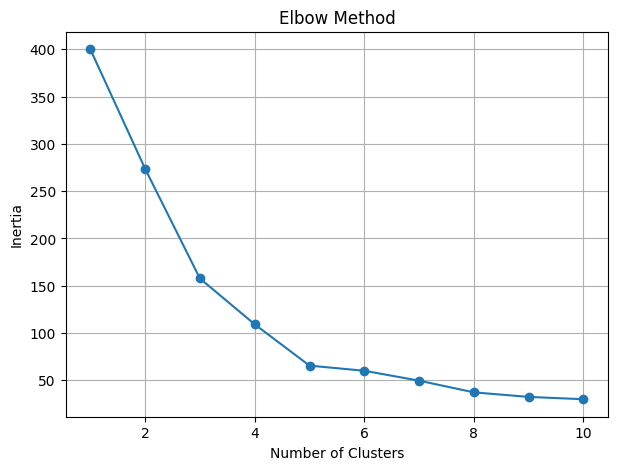

In [13]:
inertia = []  # How far points are from the center

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

Train KMeans with k=5

In [14]:
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)


Plot the Clusters (Matplotlib Only)

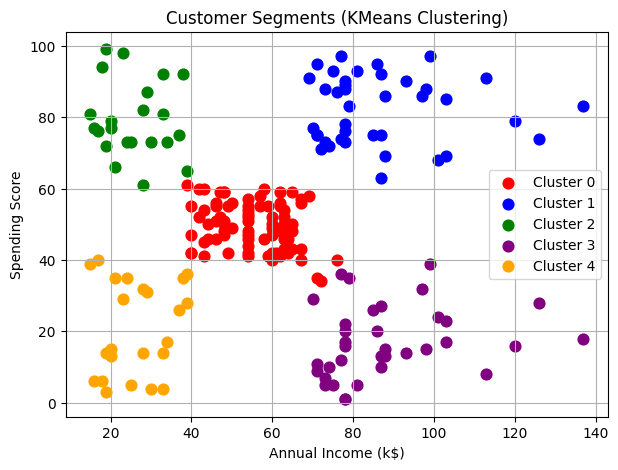

In [15]:
plt.figure(figsize=(7, 5))

colors = ['red', 'blue', 'green', 'purple', 'orange']

for cluster in range(5):
    cluster_points = df[df['Cluster'] == cluster]
    plt.scatter(
        cluster_points['Annual Income (k$)'],
        cluster_points['Spending Score (1-100)'],
        s=60,
        color=colors[cluster],
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segments (KMeans Clustering)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.grid(True)
plt.show()


Save Model

In [16]:
import joblib
joblib.dump(kmeans, "../models/kmeans_model.joblib")
print("Model saved successfully!")


FileNotFoundError: [Errno 2] No such file or directory: '../models/kmeans_model.joblib'

Analyze Clusters

In [17]:
df.groupby("Cluster")[['Annual Income (k$)', 'Spending Score (1-100)']].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043
